# 0. Environment Setup

In [1]:
# Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import re
import os

import sys
sys.path.insert(0, '..')

from src.config import (RAW_DATA_DIR, ROOT_DIR, PROCESSED_DATA_DIR, MODELS_DIR)

# Show all columns 
pd.set_option('display.max_columns', None)

# Bold Text Setup
b_start = '\033[1m'
b_end = '\033[0m'

# Graph visual style
sns.set_theme(style='whitegrid')

print('Environment Ready')

Environment Ready


-----
# 1. Complaint Narrative NLP

In [4]:
# Cleaned Dataset Load
print('Dataframe Loading...')

data = pd.read_csv(fr'{RAW_DATA_DIR}\creditcard_transactions.csv', low_memory=False)

print('Dataframe Correctly Loaded')
print()
display(data.sample(3))

Dataframe Loading...
Dataframe Correctly Loaded



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
105219,69416.0,-0.578755,1.090192,0.720793,0.855814,-0.277875,-0.359738,0.686453,0.055639,-0.699620,0.198362,1.196040,0.728077,0.146728,0.499055,0.328872,-0.030810,-0.432748,0.557013,0.653216,-0.168200,0.171540,0.586957,0.002850,0.346863,-0.179047,-0.391663,-0.411369,-0.297323,64.88,0
44916,42137.0,1.454383,-1.281154,0.746324,-1.344453,-1.850679,-0.386390,-1.480408,0.122816,-1.267091,1.447587,-0.668222,-1.989525,-1.627808,-0.032955,1.332994,-0.339196,0.777357,0.127419,-0.785127,-0.492205,-0.058358,0.175338,0.055987,0.018651,0.193606,-0.066651,0.054050,0.019198,12.00,0
201436,133887.0,1.600172,-1.154745,-0.868760,0.585371,-0.713191,-0.244823,-0.323576,-0.059547,1.199889,0.021425,-1.659139,-0.493538,-0.598341,0.132967,1.037407,0.807481,-0.889591,0.534269,-0.256689,0.238581,0.270057,0.356199,-0.107746,-0.692988,-0.304241,0.379284,-0.064151,-0.012894,240.00,0


Variables defined and scaled
=== Non Supervised Isolation Forest (contamination = 0.001)===
Total number of data points: 227845
Number of predicted anomalies (-1) with contamination = 0.001: 456
Number of predicted inliers (1) with contamination = 0.001: 227389

=== Classification Report (contamination = 0.001)===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.38      0.21      0.27        98

    accuracy                           1.00     56962
   macro avg       0.69      0.61      0.64     56962
weighted avg       1.00      1.00      1.00     56962

=== Confusion Matrix (contamination = 0.001)===


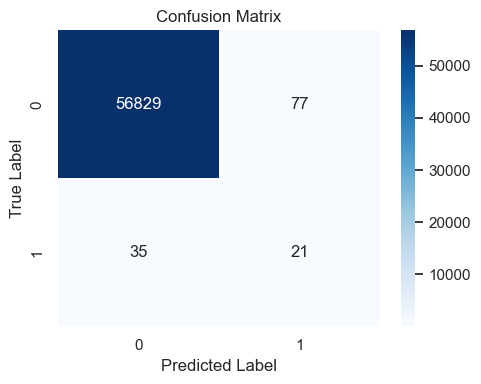

=== Non Supervised Isolation Forest (contamination = 0.002)===
Total number of data points: 227845
Number of predicted anomalies (-1) with contamination = 0.002: 456
Number of predicted inliers (1) with contamination = 0.002: 227389

=== Classification Report (contamination = 0.002)===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.34      0.39      0.36        98

    accuracy                           1.00     56962
   macro avg       0.67      0.69      0.68     56962
weighted avg       1.00      1.00      1.00     56962

=== Confusion Matrix (contamination = 0.002)===


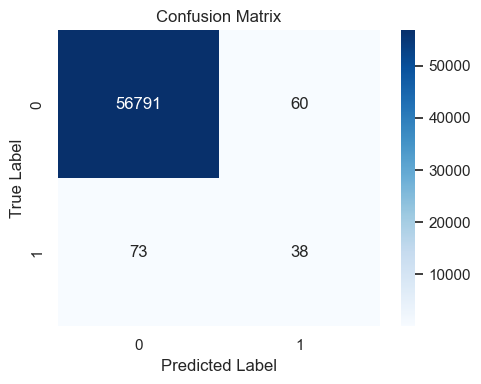

=== Non Supervised Isolation Forest (contamination = 0.005)===
Total number of data points: 227845
Number of predicted anomalies (-1) with contamination = 0.005: 456
Number of predicted inliers (1) with contamination = 0.005: 227389

=== Classification Report (contamination = 0.005)===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.18      0.49      0.26        98

    accuracy                           1.00     56962
   macro avg       0.59      0.74      0.63     56962
weighted avg       1.00      1.00      1.00     56962

=== Confusion Matrix (contamination = 0.005)===


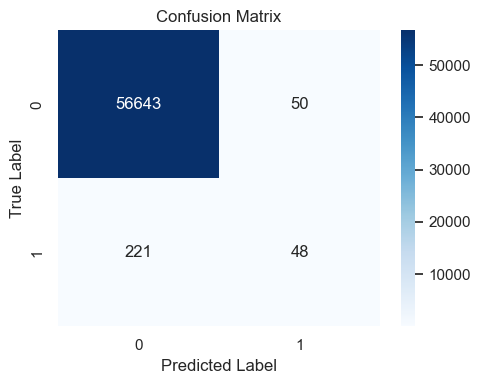

=== Non Supervised Isolation Forest (contamination = 0.01)===
Total number of data points: 227845
Number of predicted anomalies (-1) with contamination = 0.01: 456
Number of predicted inliers (1) with contamination = 0.01: 227389

=== Classification Report (contamination = 0.01)===
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.11      0.62      0.19        98

    accuracy                           0.99     56962
   macro avg       0.56      0.81      0.59     56962
weighted avg       1.00      0.99      0.99     56962

=== Confusion Matrix (contamination = 0.01)===


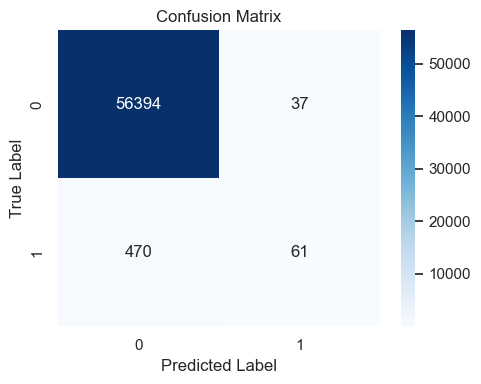

In [14]:
# Generate confusion matrix
def plot_confusion_matrix(preds, targets):
    cm = confusion_matrix(targets, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()
        
# Scale Amount and Time variables
scaler = StandardScaler()

data['scaled_amount'] = scaler.fit_transform(data[['Amount']])
data['scaled_time'] = scaler.fit_transform(data[['Time']])

# Define X and y values
X = data.drop(columns=['Class', 'Amount', 'Time'])
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=16, stratify=y)
print('Variables defined and scaled')
print()

contamination_set = [0.001, 0.002, 0.005, 0.01]
random_state = 101

for c in contamination_set:
    # Initialize and train the Isolation Forest model
    iso_forest = IsolationForest(
        contamination=c, # Check out other configurations for actual value
        random_state=random_state, 
        n_jobs=-1
    )
    
    iso_forest.fit(X_train)
    
    # Predict anomalies (-1 for outlier, 1 for inlier)
    predictions = iso_forest.predict(X_test)
    predictions_mapped = np.where(predictions == -1, 1, 0)
    
    # Print the number of predicted anomalies
    print(f'{b_start}=== Non Supervised Isolation Forest (contamination = {c})==={b_end}')
    print(f'Total number of data points: {len(X_train)}')
    print(f'Number of predicted anomalies (-1) with contamination = {c}: {np.sum(anomalies == -1)}')
    print(f'Number of predicted inliers (1) with contamination = {c}: {np.sum(anomalies == 1)}')
    print()
    print(f'{b_start}=== Classification Report (contamination = {c})==={b_end}')
    print(classification_report(y_test, predictions_mapped))
    print(f'{b_start}=== Confusion Matrix (contamination = {c})==={b_end}')
    plot_confusion_matrix(y_test, predictions_mapped)

    random_state += 1

In [20]:
# Enriched Dataframe Export
file_name = 'topic_enriched_complaints.csv'
data.to_csv(fr'{PROCESSED_DATA_DIR}\{file_name}', index=False, sep=';')
print(f'Dataframe {file_name} exported to folder {PROCESSED_DATA_DIR}')

# Topics Dataframe Export
file_name = 'topic_info.csv'
topics_df.to_csv(fr'{PROCESSED_DATA_DIR}\{file_name}', index=False, sep=';')
print(f'Dataframe {file_name} exported to folder {PROCESSED_DATA_DIR}')

Dataframe topic_enriched_complaints.csv exported to folder C:\Users\ASUS\OneDrive\Desktop\Proyectos\Consumer-Complaints-Fraud-Correlation-Analysis\notebooks\..\data\processed_data
Dataframe topic_info.csv exported to folder C:\Users\ASUS\OneDrive\Desktop\Proyectos\Consumer-Complaints-Fraud-Correlation-Analysis\notebooks\..\data\processed_data
